# **Imports + Config + Seed**

In [1]:
import os
import json
import time
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from torch.utils.data import DataLoader, WeightedRandomSampler

from sklearn.metrics import confusion_matrix, classification_report
import torch.nn as nn

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Config
BATCH_SIZE = 32
EPOCHS = 15
NUM_CLASSES = 43

TRAIN_PATH = "../dataset/train"
VAL_PATH = "../dataset/val"
TEST_PATH = "../dataset/test"

# Output dirs
os.makedirs("outputs/model", exist_ok=True)
os.makedirs("outputs/plots", exist_ok=True)
os.makedirs("outputs/logs", exist_ok=True)

# **Transforms**

In [2]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# **Load Dataset**

In [3]:
train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_PATH, transform=val_transform)
test_dataset = datasets.ImageFolder(TEST_PATH, transform=val_transform)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 33318
Val: 5891
Test: 12630


# **Class Weights + Sampler**

In [4]:
labels = [label for _, label in train_dataset]
class_counts = np.bincount(labels)

inv_class_weights = 1. / class_counts
sample_weights = [inv_class_weights[label] for label in labels]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

class_weights = torch.tensor(inv_class_weights, dtype=torch.float32).to(DEVICE)

# **DataLoaders**

In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=0
)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# **Model**

In [6]:
pretrained_weights = MobileNet_V2_Weights.DEFAULT
model = mobilenet_v2(weights=pretrained_weights)

model.classifier[1] = nn.Linear(model.last_channel, NUM_CLASSES)
model = model.to(DEVICE)

# **Freeze Layers**

In [7]:
for param in model.features.parameters():
    param.requires_grad = False

# **Loss + Optimizer + Scheduler**

In [8]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

# **Training Loop**

In [9]:
train_losses = []
val_losses = []
val_accuracies = []

best_acc = 0
patience = 3
counter = 0

for epoch in range(EPOCHS):

    start_time = time.time()

    # ===== TRAIN =====
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    # ===== VALIDATION =====
    model.eval()
    correct, total = 0, 0
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    val_loss /= len(val_loader)

    val_losses.append(val_loss)
    val_accuracies.append(acc)

    # ===== SAVE BEST MODEL + EARLY STOP =====
    if acc > best_acc:
        best_acc = acc
        counter = 0

        torch.save(model.state_dict(), "outputs/model/best_model.pth")
        print("✅ Saved best model")

    else:
        counter += 1

    # ===== UNFREEZE BACKBONE =====
    if epoch == 4:
        for param in model.features.parameters():
            param.requires_grad = True

        optimizer.add_param_group({
            "params": model.features.parameters(),
            "lr": 3e-5
        })

        print("🔥 Backbone unfrozen")

    scheduler.step()

    print(f"Epoch {epoch+1} | "
          f"Train Loss: {epoch_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {acc:.4f} | "
          f"LR: {scheduler.get_last_lr()[0]:.6f} | "
          f"Time: {time.time()-start_time:.1f}s")

    if counter >= patience:
        print("⛔ Early stopping triggered")
        break

✅ Saved best model
Epoch 1 | Train Loss: 2.3956 | Val Loss: 2.7778 | Val Acc: 0.2246 | LR: 0.000297 | Time: 1107.8s
✅ Saved best model
Epoch 2 | Train Loss: 1.5735 | Val Loss: 2.2149 | Val Acc: 0.3690 | LR: 0.000287 | Time: 1110.6s
✅ Saved best model
Epoch 3 | Train Loss: 1.2818 | Val Loss: 2.0836 | Val Acc: 0.3959 | LR: 0.000271 | Time: 1081.0s
✅ Saved best model
Epoch 4 | Train Loss: 1.1246 | Val Loss: 1.8796 | Val Acc: 0.4529 | LR: 0.000250 | Time: 1054.8s
✅ Saved best model
🔥 Backbone unfrozen
Epoch 5 | Train Loss: 1.0240 | Val Loss: 1.7600 | Val Acc: 0.4658 | LR: 0.000225 | Time: 1065.2s
✅ Saved best model
Epoch 6 | Train Loss: 0.3707 | Val Loss: 0.4351 | Val Acc: 0.8611 | LR: 0.000196 | Time: 2468.6s
✅ Saved best model
Epoch 7 | Train Loss: 0.1020 | Val Loss: 0.2260 | Val Acc: 0.9311 | LR: 0.000166 | Time: 2402.7s
✅ Saved best model
Epoch 8 | Train Loss: 0.0495 | Val Loss: 0.1438 | Val Acc: 0.9552 | LR: 0.000134 | Time: 2438.5s
✅ Saved best model
Epoch 9 | Train Loss: 0.0305 | Va

# **Save Training Curves**

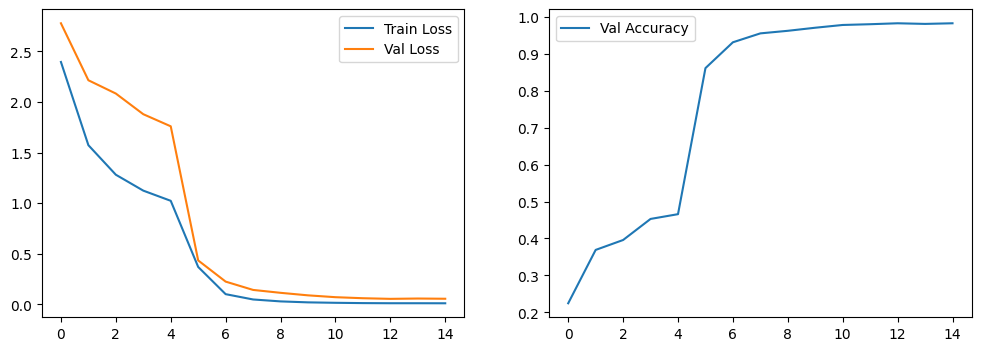

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label="Train Loss")
ax1.plot(val_losses, label="Val Loss")
ax1.legend()

ax2.plot(val_accuracies, label="Val Accuracy")
ax2.legend()

plt.savefig("outputs/plots/curves.png", dpi=300)
plt.show()

# **Test + Confusion Matrix**

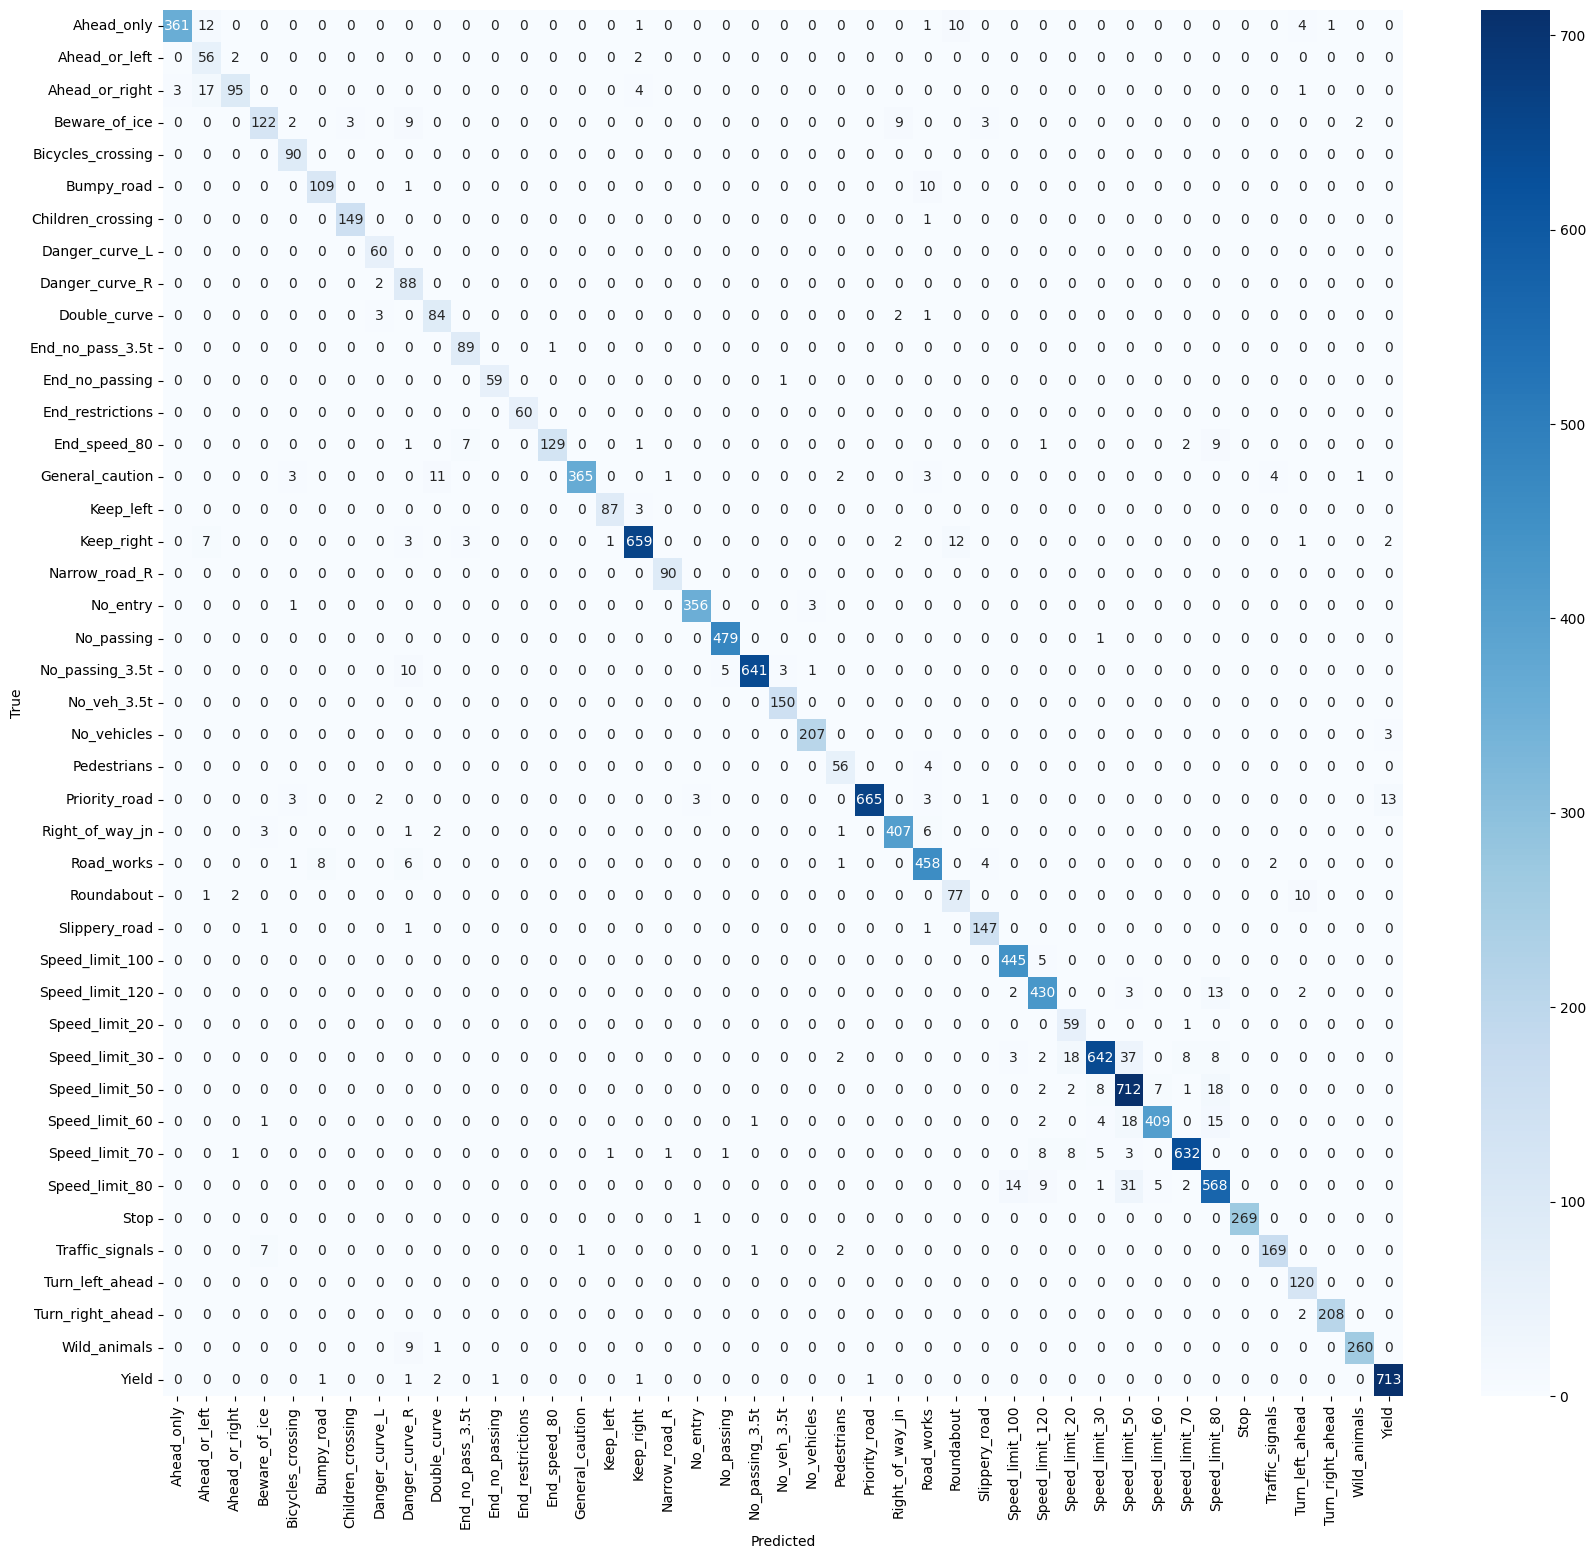

In [11]:
all_preds = []
all_labels = []

model.load_state_dict(torch.load("outputs/model/best_model.pth"))

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

class_labels = train_dataset.classes

plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_labels,
            yticklabels=class_labels,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")

plt.savefig("outputs/plots/cm.png", dpi=300)
plt.show()

# **Classification Report**

In [12]:
report = classification_report(all_labels, all_preds, output_dict=True)

with open("outputs/logs/report.json", "w") as f:
    json.dump(report, f, indent=4)

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.99      0.93      0.96       390
           1       0.60      0.93      0.73        60
           2       0.95      0.79      0.86       120
           3       0.91      0.81      0.86       150
           4       0.90      1.00      0.95        90
           5       0.92      0.91      0.92       120
           6       0.98      0.99      0.99       150
           7       0.90      1.00      0.94        60
           8       0.68      0.98      0.80        90
           9       0.84      0.93      0.88        90
          10       0.90      0.99      0.94        90
          11       0.98      0.98      0.98        60
          12       1.00      1.00      1.00        60
          13       0.99      0.86      0.92       150
          14       1.00      0.94      0.97       390
          15       0.98      0.97      0.97        90
          16       0.98      0.96      0.97       690
          17       0.98    

# **Top-5 Accuracy**

In [13]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        outputs = model(images)
        _, preds = outputs.topk(5, dim=1)

        for i in range(len(labels)):
            if labels[i] in preds[i]:
                correct += 1

        total += labels.size(0)

print("Top-5 Accuracy:", correct / total)

Top-5 Accuracy: 0.9960411718131433


# **Save Model**

In [14]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "model_name": "mobilenet_v2",
    "num_classes": NUM_CLASSES,
    "image_size": 224,
    "best_acc": best_acc,
    "class_to_idx": train_dataset.class_to_idx,
    "seed": SEED
}, "outputs/model/mobilenetv2_full.pth")

print("✅ Full checkpoint saved")

torch.save(
    model.state_dict(),
    "outputs/model/mobilenetv2_inference.pth"
)

print("✅ Inference model saved")

✅ Full checkpoint saved
✅ Inference model saved


# **Save Experiment Config**

In [15]:
config = {
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": 3e-4,
    "model": "mobilenet_v2",
    "num_classes": NUM_CLASSES,
    "seed": SEED
}

with open("outputs/logs/config.json", "w") as f:
    json.dump(config, f, indent=4)